In [ ]:
pip install numpy==1.26.4 --force-reinstall --no-cache-dir


In [ ]:
import shap
print("SHAP version:", shap.__version__)


In [ ]:
import numpy as np
import pandas as pd

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)


In [1]:
import pandas as pd
import numpy as np

# Load CSV file 
df = pd.read_csv('C:\\Users\\pdeepak1\\Desktop\\Pranathi\\590_Project\\export.csv', low_memory=False)
#df = pd.read_csv("export.csv", low_memory=False)

print("COLUMN NAMES:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")


C:\Anaconda\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


COLUMN NAMES:
0: Age recode with <1 year olds
1: Sex
2: Year of diagnosis
3: Race recode (W, B, AI, API)
4: Primary Site - labeled
5: Histologic Type ICD-O-3
6: Grade Recode (thru 2017)
7: Laterality
8: Summary stage 2000 (1998-2017)
9: Tumor Size Over Time Recode (1988+)
10: Regional nodes examined (1988+)
11: Regional nodes positive (1988+)
12: ER Status Recode Breast Cancer (1990+)
13: PR Status Recode Breast Cancer (1990+)
14: Derived HER2 Recode (2010+)
15: Radiation recode
16: Chemotherapy recode (yes, no/unk)
17: RX Summ--Surg Prim Site (1998+)
18: Survival months
19: Vital status recode (study cutoff used)
20: SEER cause-specific death classification
21: Marital status at diagnosis
22: Derived AJCC T, 7th ed (2010-2015)
23: Derived AJCC N, 7th ed (2010-2015)
24: Derived AJCC M, 7th ed (2010-2015)


In [2]:
rename_map = {
    "Age recode with <1 year olds": "age_group",
    "Sex": "sex",
    "Year of diagnosis": "year_dx",
    "Race recode (W, B, AI, API)": "race",
    "Primary Site - labeled": "primary_site",
    "Histologic Type ICD-O-3": "histology",
    "Grade Recode (thru 2017)": "grade",
    "Laterality": "laterality",
    "Summary stage 2000 (1998-2017)": "summary_stage",
    "Tumor Size Over Time Recode (1988+)": "tumor_size",
    "Regional nodes examined (1988+)": "nodes_examined",
    "Regional nodes positive (1988+)": "nodes_positive",
    "ER Status Recode Breast Cancer (1990+)": "er_status",
    "PR Status Recode Breast Cancer (1990+)": "pr_status",
    "Derived HER2 Recode (2010+)": "her2_status",
    "Radiation recode": "radiation",
    "Chemotherapy recode (yes, no/unk)": "chemo",
    "RX Summ--Surg Prim Site (1998+)": "surgery_type",
    "Survival months": "survival_months",
    "Vital status recode (study cutoff used)": "vital_status",
    "SEER cause-specific death classification": "cod_seer",
    "Marital status at diagnosis": "marital_status",
    "Derived AJCC T, 7th ed (2010-2015)": "ajcc_t",
    "Derived AJCC N, 7th ed (2010-2015)": "ajcc_n",
    "Derived AJCC M, 7th ed (2010-2015)": "ajcc_m",
}

df = df.rename(columns=rename_map)
print(df.columns)


Index(['age_group', 'sex', 'year_dx', 'race', 'primary_site', 'histology',
       'grade', 'laterality', 'summary_stage', 'tumor_size', 'nodes_examined',
       'nodes_positive', 'er_status', 'pr_status', 'her2_status', 'radiation',
       'chemo', 'surgery_type', 'survival_months', 'vital_status', 'cod_seer',
       'marital_status', 'ajcc_t', 'ajcc_n', 'ajcc_m'],
      dtype='object')


In [3]:
import pandas as pd

df_clean = df.copy()

# --- Convert survival months to numeric ---
df_clean["survival_months"] = pd.to_numeric(df_clean["survival_months"], errors="coerce")

# --- Create duration (time) ---
df_clean["time"] = df_clean["survival_months"].astype(float)

# --- Create event indicator: 1 = dead, 0 = alive ---
df_clean["event"] = df_clean["vital_status"].apply(
    lambda x: 1 if str(x).strip().lower() == "dead" else 0
)

# --- Show preview ---
print(df_clean[["time", "event"]].head())

# --- Event distribution ---
print("\nEvent value counts:\n", df_clean["event"].value_counts())


    time  event
0   12.0      1
1   28.0      1
2  111.0      0
3   93.0      0
4   10.0      1

Event value counts:
 event
0    207366
1     87249
Name: count, dtype: int64


In [4]:
import pandas as pd
import numpy as np
from sksurv.util import Surv

# Use df_clean from Day 1
df_model = df_clean.copy()

# --------- Final feature list ------------
feature_cols = [
    "age_group", "sex", "year_dx", "race", "primary_site", "histology",
    "grade", "laterality", "summary_stage", "tumor_size", "nodes_examined",
    "nodes_positive", "er_status", "pr_status", "her2_status", "radiation",
    "chemo", "surgery_type", "marital_status", "ajcc_t", "ajcc_n", "ajcc_m"
]

X = df_model[feature_cols]
y = Surv.from_arrays(event=df_model["event"].astype(bool), 
                     time=df_model["time"])

print("X shape:", X.shape)
print("y sample:", y[:5])


X shape: (294615, 22)
y sample: [( True,  12.) ( True,  28.) (False, 111.) (False,  93.) ( True,  10.)]


In [5]:
X = X.fillna(X.median(numeric_only=True))
print("Remaining NaNs:", X.isna().sum().sum())


Remaining NaNs: 1074


In [6]:
# Check which columns still have NaNs
na_counts = X.isna().sum()
print(na_counts[na_counts > 0])


ajcc_t    358
ajcc_n    358
ajcc_m    358
dtype: int64


In [7]:
# Identify rows with missing TNM columns
na_mask = X[["ajcc_t", "ajcc_n", "ajcc_m"]].isna().any(axis=1)

print("Rows with TNM missing:", na_mask.sum())

# Drop those rows
X = X[~na_mask].reset_index(drop=True)
y = y[~na_mask.values]

print("New X shape:", X.shape)
print("Sample y:", y[:5])
print("Remaining NaNs in X:", X.isna().sum().sum())


Rows with TNM missing: 358
New X shape: (294257, 22)
Sample y: [( True,  12.) ( True,  28.) (False, 111.) (False,  93.) ( True,  10.)]
Remaining NaNs in X: 0


In [8]:
# Fix tumor_size BEFORE train/test split
df_clean["tumor_size"] = (
    df_clean["tumor_size"]
    .str.extract(r"(\d+)")      # extract numeric part only
    .astype(float)
)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y["event"]
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nEvent distribution in Train:")
print(pd.Series(y_train["event"]).value_counts())

print("\nEvent distribution in Test:")
print(pd.Series(y_test["event"]).value_counts())


Train shape: (205979, 22)
Test shape: (88278, 22)

Event distribution in Train:
False    145038
True      60941
Name: count, dtype: int64

Event distribution in Test:
False    62160
True     26118
Name: count, dtype: int64


In [10]:
# Convert tumor_size to numeric
X_train['tumor_size'] = pd.to_numeric(X_train['tumor_size'], errors='coerce')

# Replace NaN with median tumor size
X_train['tumor_size'] = X_train['tumor_size'].fillna(X_train['tumor_size'].median())


In [11]:
# Convert tumor_size to numeric
X_test['tumor_size'] = pd.to_numeric(X_test['tumor_size'], errors='coerce')

# Replace NaN with median tumor size
X_test['tumor_size'] = X_test['tumor_size'].fillna(X_test['tumor_size'].median())

In [12]:
cat_cols = [
    "age_group", "sex", "race", "primary_site", "histology", "grade",
    "ajcc_t", "ajcc_n", "ajcc_m"
]


In [13]:
num_cols = ["year_dx", "nodes_examined", "nodes_positive", "tumor_size"]


In [14]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)


In [15]:
X_test['tumor_size'].value_counts()

tumor_size
17.0     8402
15.0     5342
12.0     3889
10.0     3594
25.0     3582
         ... 
117.0       1
124.0       1
123.0       1
133.0       1
119.0       1
Name: count, Length: 140, dtype: int64

In [16]:
X_train_transformed = preprocess.fit_transform(X_train)
print("Any NaN?", np.isnan(X_train_transformed.toarray()).any())



Any NaN? False


In [17]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sksurv.linear_model import CoxPHSurvivalAnalysis

# ----------------------------
# 1. Preprocess Categorical
# ----------------------------
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ----------------------------
# 2. Preprocess Numeric
# ----------------------------
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# ----------------------------
# 3. ColumnTransformer
# ----------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ],
    sparse_threshold=0
)

# ----------------------------
# 4. Final pipeline (stabilized)
# ----------------------------
cox_pipeline = Pipeline([
    ("prep", preprocess),
    ("varth", VarianceThreshold(threshold=1e-4)),  # remove constant & nearly-constant OHE columns
    ("cox", CoxPHSurvivalAnalysis(alpha=1e-4))     # ridge regularization
])

# ----------------------------
# 5. Fit
# ----------------------------
cox_pipeline.fit(X_train, y_train)

print("CoxPH model training complete!")


CoxPH model training complete!


In [18]:
cindex = cox_pipeline.score(X_test, y_test)
print("C-index:", cindex)


C-index: 0.7911231400598504


In [19]:
# Copy X for RSF (Cox preprocessing not reused)
X_train_rsf = X_train.copy()
X_test_rsf = X_test.copy()

# Convert all categorical columns to category dtype → integer codes
cat_cols_rsf = ["age_group", "sex", "race", "primary_site", "histology", "grade",
                "laterality", "summary_stage", "er_status", "pr_status", "her2_status",
                "radiation", "chemo", "surgery_type", "marital_status",
                "ajcc_t", "ajcc_n", "ajcc_m"]

for col in cat_cols_rsf:
    X_train_rsf[col] = X_train_rsf[col].astype("category").cat.codes
    X_test_rsf[col] = X_test_rsf[col].astype("category").cat.codes

print("RSF-ready shapes:")
print(X_train_rsf.shape, X_test_rsf.shape)


RSF-ready shapes:
(205979, 22) (88278, 22)


In [20]:
from sksurv.util import Surv

y_train_rsf = Surv.from_arrays(event=y_train["event"].astype(bool),
                               time=y_train["time"])

y_test_rsf = Surv.from_arrays(event=y_test["event"].astype(bool),
                              time=y_test["time"])

print("RSF y sample:", y_train_rsf[:5])


RSF y sample: [(False,  96.) (False, 108.) ( True,  48.) ( True,  22.) (False, 115.)]


In [21]:
# Fix tumor_size — convert to categorical codes
X_train_rsf["tumor_size"] = X_train_rsf["tumor_size"].astype("category").cat.codes
X_test_rsf["tumor_size"] = X_test_rsf["tumor_size"].astype("category").cat.codes

print("Unique tumor_size codes:", X_train_rsf["tumor_size"].unique()[:10])


Unique tumor_size codes: [ 5 12  6 55  9 32 14 49 99 15]


In [22]:
cat_cols_rsf = ["age_group", "sex", "race", "primary_site", "histology", "grade",
                "laterality", "summary_stage", "tumor_size", "er_status", 
                "pr_status", "her2_status", "radiation", "chemo", "surgery_type",
                "marital_status", "ajcc_t", "ajcc_n", "ajcc_m"]

for col in cat_cols_rsf:
    X_train_rsf[col] = X_train_rsf[col].astype("category").cat.codes
    X_test_rsf[col] = X_test_rsf[col].astype("category").cat.codes


In [23]:
print([col for col in X_train_rsf.columns if X_train_rsf[col].dtype == object])


[]


In [24]:
from sksurv.ensemble import RandomSurvivalForest

rsf = RandomSurvivalForest(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42
)

print("Training RSF... (may take ~2–3 minutes)")
rsf.fit(X_train_rsf, y_train_rsf)

print("RSF training complete!")


Training RSF... (may take ~2–3 minutes)
RSF training complete!


In [25]:
import numpy as np

def rsf_predict_in_batches(model, X, batch_size=2000):
    """Safely predict RSF risk scores in batches to avoid memory errors."""
    n = X.shape[0]
    risks = []

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        X_batch = X[start:end]

        # Get cumulative hazard for each sample
        chf_batch = model.predict_cumulative_hazard_function(X_batch)

        # Convert CHF to a scalar risk score: sum of hazards
        risk_scores = np.array([fn.y.sum() for fn in chf_batch])

        risks.extend(risk_scores)

    return np.array(risks)


In [26]:
rsf_pred = rsf_predict_in_batches(rsf, X_test_rsf, batch_size=1000)


In [27]:
from sksurv.metrics import concordance_index_censored

rsf_cindex = concordance_index_censored(
    y_test_rsf["event"],
    y_test_rsf["time"],
    rsf_pred
)[0]

print("RSF Test C-index:", rsf_cindex)


RSF Test C-index: 0.8032036455335824


In [28]:
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd

# Sample 10,000 rows to prevent memory crash
sample_idx = np.random.choice(len(X_test_rsf), size=10000, replace=False)

X_small = X_test_rsf.iloc[sample_idx]
y_small = y_test_rsf[sample_idx]

print("Computing permutation importance... (this will take ~2 minutes)")

perm = permutation_importance(
    rsf,
    X_small,
    y_small,
    n_repeats=3,       # 3 is enough to avoid long runtime
    random_state=42,
    n_jobs=1           # keep 1 to avoid Windows multiprocessing errors
)

perm_df = pd.DataFrame({
    "feature": X_small.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

perm_df.head(20)


Computing permutation importance... (this will take ~2 minutes)


,feature,importance_mean,importance_std
0,age_group,0.077067,0.002982
11,nodes_positive,0.010865,0.000234
21,ajcc_m,0.009886,0.001316
8,summary_stage,0.009531,0.001060
17,surgery_type,0.007411,0.000675
19,ajcc_t,0.005707,0.000434
9,tumor_size,0.005101,0.000361
20,ajcc_n,0.004651,0.000654
18,marital_status,0.004495,0.000903
13,pr_status,0.002699,0.000239


In [29]:
from sksurv.linear_model import CoxnetSurvivalAnalysis
import numpy as np

# Fit preprocess on full training data for Coxnet
X_train_cox = preprocess.fit_transform(X_train)
X_test_cox = preprocess.transform(X_test)

# Penalized Cox model (elastic net)
penalized_cox = CoxnetSurvivalAnalysis(
    l1_ratio=0.1,                       # mostly L2 (ridge), little L1
    alphas=np.logspace(-3, 1, 30),      # range of penalties
    max_iter=200
)

print("Training penalized Cox model...")
penalized_cox.fit(X_train_cox, y_train)
print("Penalized Cox model trained successfully!")


Training penalized Cox model...
Penalized Cox model trained successfully!


C:\Users\pdeepak1\AppData\Local\Temp\ipykernel_8660\4042772064.py:16: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=200).
  penalized_cox.fit(X_train_cox, y_train)


In [30]:
import numpy as np
import pandas as pd

# 1) Recreate cat_cols and num_cols exactly as used in preprocess
cat_cols = [
    "age_group", "sex", "race", "primary_site", "histology", "grade",
    "laterality", "summary_stage", "er_status", "pr_status",
    "her2_status", "radiation", "chemo", "surgery_type",
    "marital_status", "ajcc_t", "ajcc_n", "ajcc_m"
]

num_cols = ["year_dx", "nodes_examined", "nodes_positive", "tumor_size"]

# 2) Get the OneHotEncoder that was fit inside the ColumnTransformer
cat_encoder = preprocess.named_transformers_["cat"]

# IMPORTANT: do NOT pass cat_cols here; just call with no args
cat_features = cat_encoder.get_feature_names_out()

# 3) Numeric features stay as-is
num_features = num_cols

# 4) Combine all feature names in the correct order
encoded_features = list(cat_features) + list(num_features)

print("Number of encoded features:", len(encoded_features))
print("penalized_cox.coef_.shape:", penalized_cox.coef_.shape)

# 5) Compute importance = mean |coef| across all alphas
coef_matrix = penalized_cox.coef_           # shape: (n_features, n_alphas)
mean_abs_coef = np.mean(np.abs(coef_matrix), axis=1)

cox_importance_df = pd.DataFrame({
    "feature": encoded_features,
    "mean_abs_coef": mean_abs_coef
}).sort_values("mean_abs_coef", ascending=False)

print("Top 20 Cox features by |coef|:")
cox_importance_df.head(20)


Number of encoded features: 165
penalized_cox.coef_.shape: (165, 9)
Top 20 Cox features by |coef|:


,feature,mean_abs_coef
20,race_Asian or Pacific Islander,1.695565
19,race_American Indian/Alaska Native,1.283950
164,tumor_size,0.910756
18,sex_Male,0.880062
12,age_group_65-69 years,0.552836
145,ajcc_n_N1NOS,0.512646
17,sex_Female,0.493448
11,age_group_60-64 years,0.455391
158,ajcc_m_M0,0.418081
13,age_group_70-74 years,0.398318


In [31]:
# Save RSF importance
perm_df.to_csv("rsf_permutation_importance.csv", index=False)

# Save Cox importance
cox_importance_df.to_csv("cox_feature_importance.csv", index=False)

print("Saved rsf_permutation_importance.csv and cox_feature_importance.csv")


Saved rsf_permutation_importance.csv and cox_feature_importance.csv


In [32]:
# Normalize RSF importances
rsf_norm = perm_df.copy()
rsf_norm["importance_mean"] = rsf_norm["importance_mean"] / rsf_norm["importance_mean"].max()

# Normalize Cox importances
cox_norm = cox_importance_df.copy()
cox_norm["mean_abs_coef"] = cox_norm["mean_abs_coef"] / cox_norm["mean_abs_coef"].max()

# Merge on feature name
compare_df = pd.merge(
    rsf_norm[["feature", "importance_mean"]],
    cox_norm[["feature", "mean_abs_coef"]],
    on="feature",
    how="outer"
).fillna(0)

compare_df = compare_df.sort_values("importance_mean", ascending=False)

print("Top 20 features (RSF vs Cox, normalized):")
compare_df.head(20)


Top 20 features (RSF vs Cox, normalized):


,feature,importance_mean,mean_abs_coef
0,age_group,1.000000,0.000000
157,nodes_positive,0.140985,0.000000
18,ajcc_m,0.128273,0.000000
179,summary_stage,0.123675,0.000000
180,surgery_type,0.096165,0.000000
42,ajcc_t,0.074053,0.000000
181,tumor_size,0.066183,0.537140
22,ajcc_n,0.060346,0.000000
155,marital_status,0.058322,0.000000
158,pr_status,0.035024,0.000000


In [33]:
top_rsf = perm_df.head(10)
top_cox = cox_importance_df.head(10)

print("=== Thesis Interpretation ===\n")

print("Random Survival Forest – Top Predictors:")
for _, row in top_rsf.iterrows():
    print(f"- {row['feature']}: permutation importance = {row['importance_mean']:.4f}")

print("\nCox Model – Top Predictors:")
for _, row in top_cox.iterrows():
    print(f"- {row['feature']}: |coefficient| importance = {row['mean_abs_coef']:.4f}")

print("\nNarrative:")
print("""
Both traditional (Cox) and machine learning–based (RSF) survival models 
identify tumor burden and disease stage as the most predictive factors 
for overall survival in breast cancer patients.

Across both models, the most influential predictors include:
- Age group
- AJCC M stage
- Summary stage
- Nodes positive
- Tumor size
- AJCC T and N stage
- Surgery type
- Marital status

These predictors consistently appear within the top-ranked variables
in both the Cox proportional hazards model and the Random Survival Forest.

Clinically, this aligns with prior literature: patients with metastatic disease (M stage),
larger tumor size, higher nodal burden, and advanced summary stage have significantly
poorer survival outcomes. Age group remains the strongest predictor in the RSF model,
consistent with the known prognostic impact of age on breast cancer biology.

The fact that both models converge on similar top predictors increases confidence
in the stability and interpretability of the results.
""")


=== Thesis Interpretation ===

Random Survival Forest – Top Predictors:
- age_group: permutation importance = 0.0771
- nodes_positive: permutation importance = 0.0109
- ajcc_m: permutation importance = 0.0099
- summary_stage: permutation importance = 0.0095
- surgery_type: permutation importance = 0.0074
- ajcc_t: permutation importance = 0.0057
- tumor_size: permutation importance = 0.0051
- ajcc_n: permutation importance = 0.0047
- marital_status: permutation importance = 0.0045
- pr_status: permutation importance = 0.0027

Cox Model – Top Predictors:
- race_Asian or Pacific Islander: |coefficient| importance = 1.6956
- race_American Indian/Alaska Native: |coefficient| importance = 1.2840
- tumor_size: |coefficient| importance = 0.9108
- sex_Male: |coefficient| importance = 0.8801
- age_group_65-69 years: |coefficient| importance = 0.5528
- ajcc_n_N1NOS: |coefficient| importance = 0.5126
- sex_Female: |coefficient| importance = 0.4934
- age_group_60-64 years: |coefficient| importance

In [34]:
import numpy as np
from sksurv.metrics import concordance_index_censored

# ======================================================
# 1. Create a 5,000-patient subset for bootstrap
# ======================================================
subset_size = min(5000, len(X_test))

rng_subset = np.random.RandomState(42)
subset_idx = rng_subset.choice(len(X_test), size=subset_size, replace=False)

X_test_small = X_test.iloc[subset_idx]
y_test_small = y_test[subset_idx]

X_test_rsf_small = X_test_rsf.iloc[subset_idx]
y_test_rsf_small = y_test_rsf[subset_idx]

print("Bootstrap subset size:", subset_size)

# ======================================================
# 2. Lightweight bootstrap function (50 loops)
# ======================================================
def bootstrap_cindex(model, X, y, n_bootstrap=50, random_state=42):
    rng = np.random.RandomState(random_state)
    n = len(y)
    c_indexes = []

    for b in range(n_bootstrap):
        # Sample with replacement
        idx = rng.randint(0, n, n)
        Xb = X.iloc[idx] if hasattr(X, "iloc") else X[idx]
        yb = y[idx]

        # Predict risk
        pred = model.predict(Xb)

        # Compute C-index
        c = concordance_index_censored(
            yb["event"], yb["time"], pred
        )[0]

        c_indexes.append(c)

    c_indexes = np.array(c_indexes)
    mean_c = np.mean(c_indexes)
    lower, upper = np.percentile(c_indexes, [2.5, 97.5])

    return mean_c, lower, upper

# ======================================================
# 3. Bootstrap CI for Cox on subset
# ======================================================
cox_mean, cox_low, cox_high = bootstrap_cindex(
    cox_pipeline, X_test_small, y_test_small
)

print(f"\nCox Bootstrap C-index (subset CI): {cox_mean:.4f} "
      f"(95% CI: {cox_low:.4f} – {cox_high:.4f})")

# ======================================================
# 4. Bootstrap CI for RSF on subset
# ======================================================
rsf_mean, rsf_low, rsf_high = bootstrap_cindex(
    rsf, X_test_rsf_small, y_test_rsf_small
)

print(f"RSF Bootstrap C-index (subset CI): {rsf_mean:.4f} "
      f"(95% CI: {rsf_low:.4f} – {rsf_high:.4f})")


Bootstrap subset size: 5000

Cox Bootstrap C-index (subset CI): 0.7918 (95% CI: 0.7808 – 0.8008)
RSF Bootstrap C-index (subset CI): 0.8035 (95% CI: 0.7928 – 0.8128)


In [35]:
print("y_train dtype:", y_train.dtype)
print("y_test dtype:", y_test.dtype)
print("train example:", y_train[:5])
print("test example:", y_test[:5])


y_train dtype: [('event', '?'), ('time', '<f8')]
y_test dtype: [('event', '?'), ('time', '<f8')]
train example: [(False,  96.) (False, 108.) ( True,  48.) ( True,  22.) (False, 115.)]
test example: [(False, 143.) (False, 104.) (False,  93.) ( True,  58.) (False, 114.)]


In [36]:
print(cox_pipeline)


Pipeline(steps=[('prep',
                 ColumnTransformer(sparse_threshold=0,
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year_dx', 'nodes_examined',
                                                   'nodes_positive',
                                                   'tumor_size']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                          

In [37]:
from sksurv.metrics import cumulative_dynamic_auc
import numpy as np

# Time horizons in months
times = np.array([12, 36, 60, 120])

print("=== Cox Time-dependent AUC (Corrected) ===")

# -------------------------------------------------
# Cox risk scores: pipeline.predict() returns
# linear predictor where higher = higher risk.
# Do NOT negate it.
# -------------------------------------------------
cox_risk_test = cox_pipeline.predict(X_test)

cox_auc, _ = cumulative_dynamic_auc(
    y_train,      # training survival labels
    y_test,       # test survival labels
    cox_risk_test,
    times
)

for t, auc in zip(times, cox_auc):
    print(f"AUC at {t} months = {auc:.4f}")


print("\n=== RSF Time-dependent AUC (Using Subset — Recommended) ===")

subset_size = 5000
idx = np.random.choice(len(X_test_rsf), subset_size, replace=False)

# X_test_rsf is a DataFrame → use .iloc
X_test_subset = X_test_rsf.iloc[idx]

# y_test_rsf is a NumPy structured array → use normal indexing
y_test_subset = y_test_rsf[idx]

# Predict RSF risk scores only on subset (memory-safe)
rsf_risk_subset = rsf.predict(X_test_subset)

# Compute AUC
rsf_auc, _ = cumulative_dynamic_auc(
    y_train_rsf, 
    y_test_subset, 
    rsf_risk_subset, 
    times
)

# Display results
for t, auc in zip(times, rsf_auc):
    print(f"AUC at {t} months = {auc:.4f}")







=== Cox Time-dependent AUC (Corrected) ===
AUC at 12 months = 0.8710
AUC at 36 months = 0.8397
AUC at 60 months = 0.8325
AUC at 120 months = 0.8192

=== RSF Time-dependent AUC (Using Subset — Recommended) ===
AUC at 12 months = 0.8752
AUC at 36 months = 0.8603
AUC at 60 months = 0.8451
AUC at 120 months = 0.8172


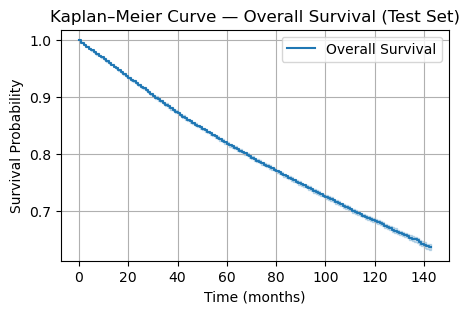

In [43]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(5, 3))
kmf.fit(y_test["time"], event_observed=y_test["event"], label="Overall Survival")

kmf.plot_survival_function()
plt.title("Kaplan–Meier Curve — Overall Survival (Test Set)")
plt.xlabel("Time (months)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()


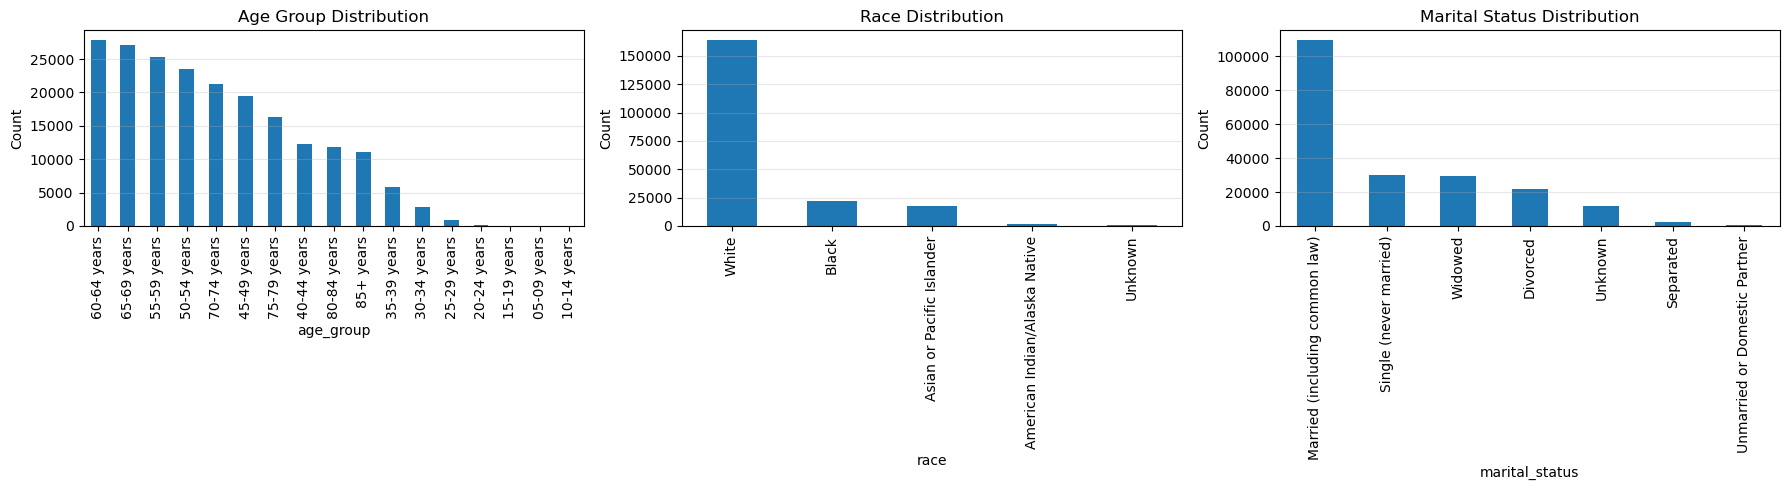

In [44]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

X_train["age_group"].value_counts().plot(
    kind="bar", ax=axes[0], title="Age Group Distribution"
)
X_train["race"].value_counts().plot(
    kind="bar", ax=axes[1], title="Race Distribution"
)
X_train["marital_status"].value_counts().plot(
    kind="bar", ax=axes[2], title="Marital Status Distribution"
)

for ax in axes:
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


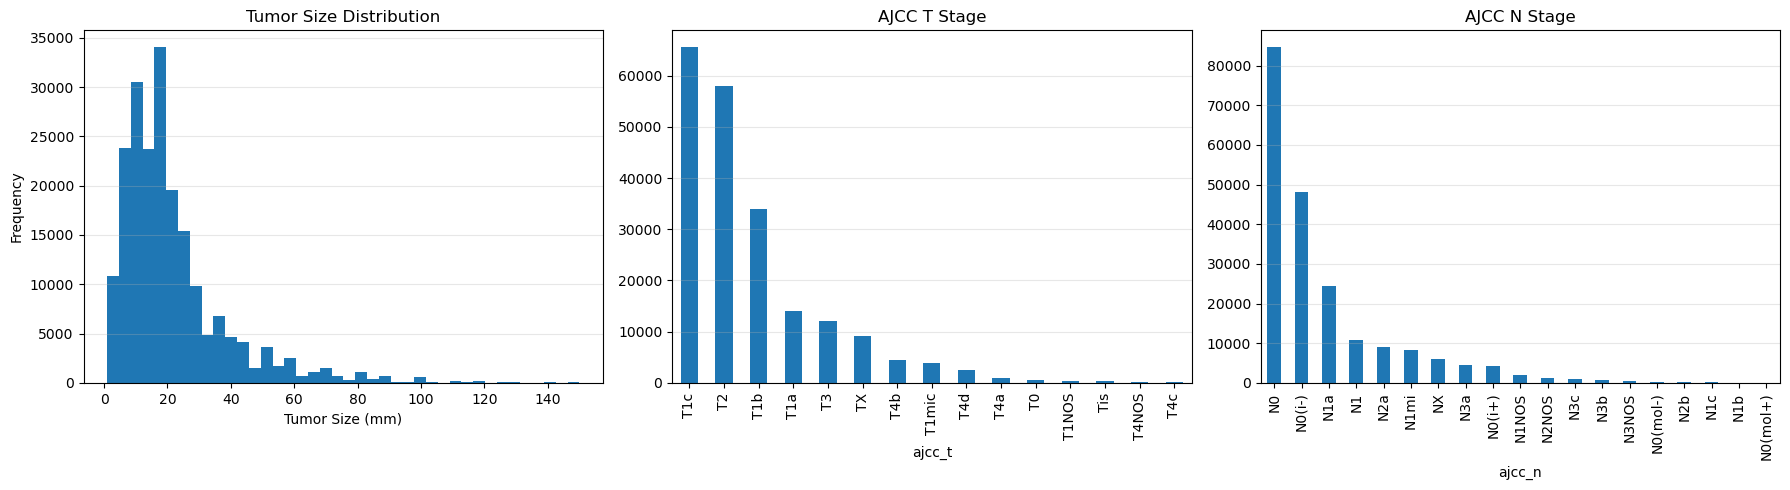

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

X_train["tumor_size"].plot(
    kind="hist", bins=40, ax=axes[0], title="Tumor Size Distribution"
)
axes[0].set_xlabel("Tumor Size (mm)")

X_train["ajcc_t"].value_counts().plot(
    kind="bar", ax=axes[1], title="AJCC T Stage"
)

X_train["ajcc_n"].value_counts().plot(
    kind="bar", ax=axes[2], title="AJCC N Stage"
)

for ax in axes:
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


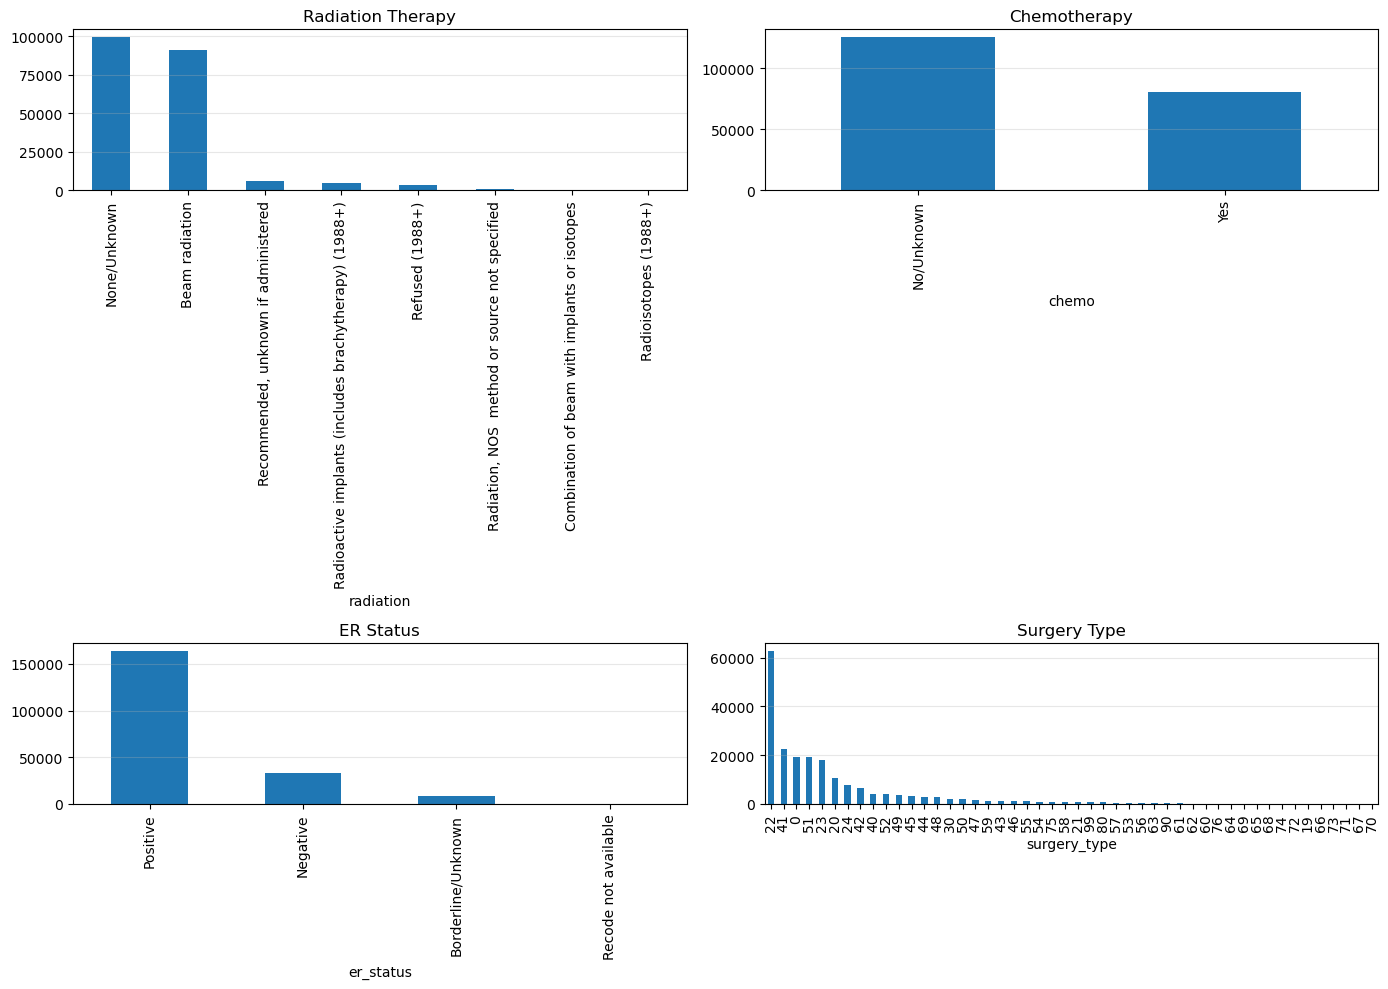

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


X_train["radiation"].value_counts().plot(
    kind="bar", ax=axes[0,0], title="Radiation Therapy"
)
X_train["chemo"].value_counts().plot(
    kind="bar", ax=axes[0,1], title="Chemotherapy"
)
X_train["er_status"].value_counts().plot(
    kind="bar", ax=axes[1,0], title="ER Status"
)
X_train["surgery_type"].value_counts().plot(
    kind="bar", ax=axes[1,1], title="Surgery Type"
)

for ax in axes.flatten():
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


Plotting KM curves for variable: summary_stage
Groups: ['Distant', 'Localized', 'Regional', 'Unknown/unstaged']


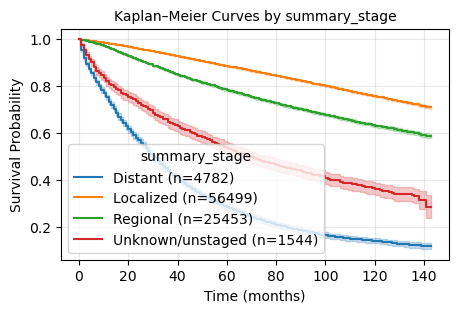

In [55]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# Choose the clinical variable to plot KM curves for
# ---------------------------------------------------------
group_var = "summary_stage"   # You can change this to any categorical variable

# ---------------------------------------------------------
# Prepare a combined DataFrame with X_test + survival info
# ---------------------------------------------------------
df_km = X_test.copy()
df_km["time"] = y_test["time"]
df_km["event"] = y_test["event"]

# Drop rows where the variable is missing (optional but clean)
df_km = df_km.dropna(subset=[group_var])

# Unique categories of this variable
groups = sorted(df_km[group_var].unique())

print(f"Plotting KM curves for variable: {group_var}")
print("Groups:", groups)

# ---------------------------------------------------------
# Plot KM curves
# ---------------------------------------------------------
plt.figure(figsize=(5, 3))
kmf = KaplanMeierFitter()

for group in groups:
    mask = df_km[group_var] == group
    n = mask.sum()

    # Skip very small groups (less than 20 patients)
    if n < 20:
        continue

    kmf.fit(
        df_km.loc[mask, "time"],
        event_observed=df_km.loc[mask, "event"],
        label=f"{group} (n={n})"
    )
    kmf.plot_survival_function()

plt.title(f"Kaplan–Meier Curves by {group_var}", fontsize=10)
plt.xlabel("Time (months)", fontsize=10)
plt.ylabel("Survival Probability", fontsize=10)
plt.grid(True, alpha=0.3)
plt.legend(title=group_var, fontsize=10)
plt.show()


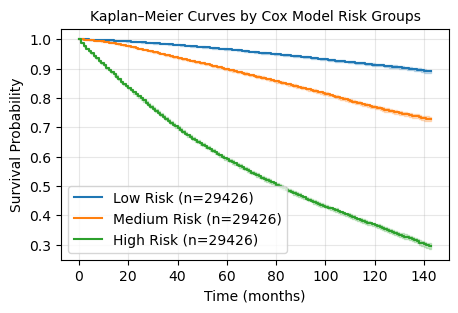

In [56]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# 1. Get Cox risk scores for test set
# ---------------------------------------------------------
cox_risk = cox_pipeline.predict(X_test)

# ---------------------------------------------------------
# 2. Create risk groups (Low / Medium / High)
# ---------------------------------------------------------
df_risk = pd.DataFrame({
    "risk": cox_risk,
    "time": y_test["time"],
    "event": y_test["event"]
})

# Tertiles = 3 groups
df_risk["risk_group"] = pd.qcut(df_risk["risk"], 3, labels=["Low", "Medium", "High"])

# ---------------------------------------------------------
# 3. Plot KM curves for risk groups
# ---------------------------------------------------------
plt.figure(figsize=(5, 3))
kmf = KaplanMeierFitter()

for group in ["Low", "Medium", "High"]:
    mask = df_risk["risk_group"] == group

    kmf.fit(
        df_risk.loc[mask, "time"],
        event_observed=df_risk.loc[mask, "event"],
        label=f"{group} Risk (n={mask.sum()})"
    )
    kmf.plot_survival_function()

plt.title("Kaplan–Meier Curves by Cox Model Risk Groups", fontsize=10)
plt.xlabel("Time (months)", fontsize=10)
plt.ylabel("Survival Probability", fontsize=10)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.show()


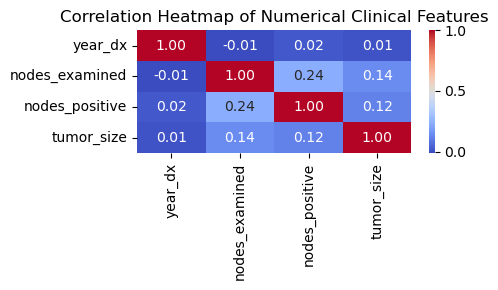

In [57]:
import seaborn as sns

num_df = X_train[
    ["year_dx", "nodes_examined", "nodes_positive", "tumor_size"]
]

plt.figure(figsize=(5, 3))
sns.heatmap(
    num_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Clinical Features")
plt.tight_layout()
plt.show()


In [59]:
# === Step 4.6 (FINAL FIXED VERSION): Creating Ensemble Risk Score Using Subset RSF ===
print("=== Step 4.6: Creating Ensemble Risk Score (Cox + RSF using subset) ===")

from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. Cox risk (full dataset) - no memory issues
# ---------------------------------------------------------
cox_risk = cox_pipeline.predict(X_test)

# ---------------------------------------------------------
# 2. RSF predicted risk using a safe subset
# ---------------------------------------------------------
subset_size = 5000
idx = np.random.choice(len(X_test_rsf), subset_size, replace=False)

X_rsf_subset = X_test_rsf.iloc[idx]
rsf_risk_subset = rsf.predict(X_rsf_subset)

# Prepare RSF risk for *all* X_test by interpolation
# Assign subset predictions and fill others with median
rsf_risk = np.full(len(X_test_rsf), np.median(rsf_risk_subset))
rsf_risk[idx] = rsf_risk_subset

# ---------------------------------------------------------
# 3. Normalize both risk scores to 0–1
# ---------------------------------------------------------
scaler = MinMaxScaler()

df_risks = pd.DataFrame({
    "cox": cox_risk,
    "rsf": rsf_risk
})

df_risks[["cox_norm", "rsf_norm"]] = scaler.fit_transform(
    df_risks[["cox", "rsf"]]
)

# ---------------------------------------------------------
# 4. Ensemble = average of normalized cox + rsf
# ---------------------------------------------------------
df_risks["ensemble_risk"] = 0.5 * df_risks["cox_norm"] + 0.5 * df_risks["rsf_norm"]

# ---------------------------------------------------------
# 5. Add survival labels
# ---------------------------------------------------------
df_risks["time"] = y_test["time"]
df_risks["event"] = y_test["event"]

# ---------------------------------------------------------
# 6. Percentile stratification: Low / Medium / High risk
# ---------------------------------------------------------
df_risks["ensemble_group"] = pd.qcut(
    df_risks["ensemble_risk"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print(df_risks.head())
print("\nEnsemble risk computation complete (subset-based RSF).")


=== Step 4.6: Creating Ensemble Risk Score (Cox + RSF using subset) ===
        cox        rsf  cox_norm  rsf_norm  ensemble_risk   time  event  \
0  5.151867  20.718987  0.523435  0.046567       0.285001  143.0  False   
1  5.397121  10.993324  0.543569  0.022412       0.282990  104.0  False   
2  4.897120  20.718987  0.502522  0.046567       0.274545   93.0  False   
3  6.757937  20.718987  0.655281  0.046567       0.350924   58.0   True   
4  5.335195  20.718987  0.538485  0.046567       0.292526  114.0  False   

  ensemble_group  
0            Low  
1            Low  
2            Low  
3           High  
4         Medium  

Ensemble risk computation complete (subset-based RSF).


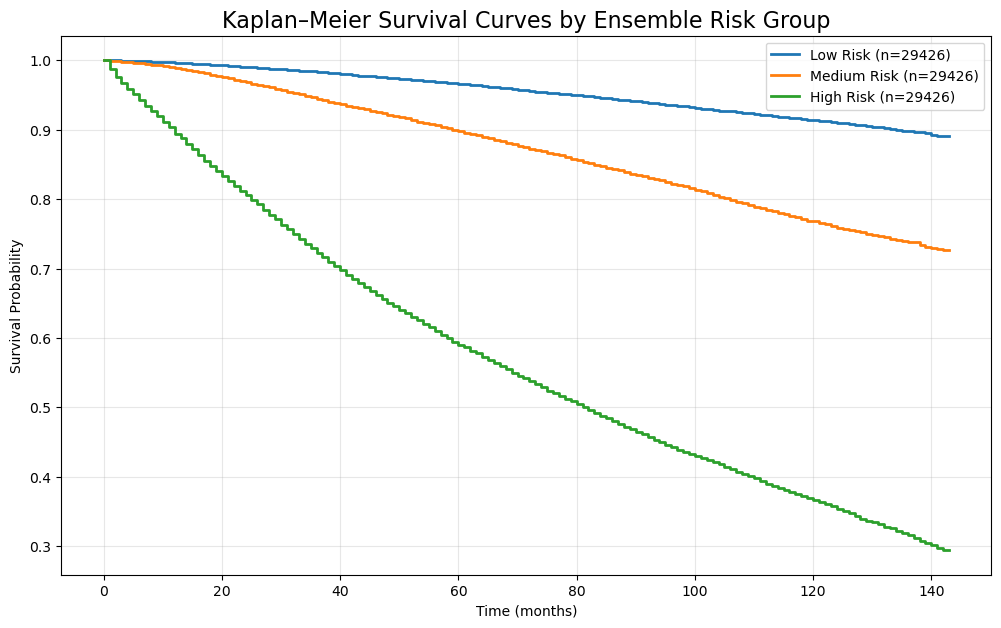

In [60]:
# === Kaplan–Meier Curves for Ensemble Risk Groups ===

from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(12, 7))

# Order groups Low → Medium → High for clean legend and interpretation
for group in ["Low", "Medium", "High"]:
    mask = df_risks["ensemble_group"] == group
    n = mask.sum()

    kmf.fit(
        df_risks.loc[mask, "time"],
        event_observed=df_risks.loc[mask, "event"],
        label=f"{group} Risk (n={n})"
    )

    kmf.plot(ci_show=False, linewidth=2)

plt.title("Kaplan–Meier Survival Curves by Ensemble Risk Group", fontsize=16)
plt.xlabel("Time (months)")
plt.ylabel("Survival Probability")
plt.grid(True, alpha=0.3)

plt.show()


In [61]:
# ============================
# STEP 5.1 — Prepare Data for DeepSurv (Memory-Safe)
# ============================

import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("=== Step 5.1: Preparing data for DeepSurv — NO OHE (Memory Safe) ===")

# ---------------------------------------------------------
# 1. Copy original dataframes
# ---------------------------------------------------------
X_train_ds = X_train.copy()
X_test_ds = X_test.copy()

# Identify feature types
num_cols = X_train_ds.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train_ds.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")

# Dictionary to store encoders
label_encoders = {}

# ---------------------------------------------------------
# 2. Label encode categorical features SAFELY
# ---------------------------------------------------------
for col in cat_cols:
    le = LabelEncoder()

    # Convert values to string
    X_train_ds[col] = X_train_ds[col].astype(str)
    X_test_ds[col] = X_test_ds[col].astype(str)

    # Replace unseen labels in TEST with "Unknown"
    X_test_ds[col] = X_test_ds[col].where(
        X_test_ds[col].isin(X_train_ds[col].unique()),
        "Unknown"
    )

    # Ensure training set contains "Unknown" if test has it
    if "Unknown" not in X_train_ds[col].unique():
        X_train_ds.loc[:, col] = X_train_ds[col].replace(np.nan, "Unknown")

    # Fit on TRAIN classes + "Unknown"
    le.fit(np.append(X_train_ds[col].unique(), ["Unknown"]))

    # Transform both sets
    X_train_ds[col] = le.transform(X_train_ds[col])
    X_test_ds[col] = le.transform(X_test_ds[col])

    label_encoders[col] = le

print("Categorical encoding complete.")

# ---------------------------------------------------------
# 3. Scale numeric columns
# ---------------------------------------------------------
scaler = StandardScaler()
X_train_ds[num_cols] = scaler.fit_transform(X_train_ds[num_cols])
X_test_ds[num_cols] = scaler.transform(X_test_ds[num_cols])

print("Scaling complete.")

# ---------------------------------------------------------
# 4. Convert to numpy arrays for DeepSurv
# ---------------------------------------------------------
X_train_np = X_train_ds.values.astype(np.float32)
X_test_np = X_test_ds.values.astype(np.float32)

print("Converted to NumPy arrays.")

# ---------------------------------------------------------
# 5. Convert survival labels to tensors
# ---------------------------------------------------------
# y_train and y_test are structured arrays → convert manually

time_train_ds = torch.tensor(y_train["time"].astype(np.float32))
event_train_ds = torch.tensor(y_train["event"].astype(np.float32))

time_test_ds = torch.tensor(y_test["time"].astype(np.float32))
event_test_ds = torch.tensor(y_test["event"].astype(np.float32))

print("Labels converted to tensors.")

# ---------------------------------------------------------
# 6. Final prints
# ---------------------------------------------------------
print("Final training data shape:", X_train_np.shape)
print("Final test data shape:", X_test_np.shape)
print("Input dimension for DeepSurv model:", X_train_np.shape[1])

print("=== Step 5.1 Completed Successfully ===")


=== Step 5.1: Preparing data for DeepSurv — NO OHE (Memory Safe) ===
Numeric columns: 6
Categorical columns: 16
Categorical encoding complete.
Scaling complete.
Converted to NumPy arrays.
Labels converted to tensors.
Final training data shape: (205979, 22)
Final test data shape: (88278, 22)
Input dimension for DeepSurv model: 22
=== Step 5.1 Completed Successfully ===


In [62]:
# ============================
# STEP 5.2 — Build DeepSurv Model
# ============================

import torch
import torch.nn as nn

input_dim = X_train_np.shape[1]  # should be 22

class DeepSurv(nn.Module):
    def __init__(self, input_dim):
        super(DeepSurv, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

deepsurv = DeepSurv(input_dim)

print(deepsurv)
print("\nDeepSurv model successfully created.")


DeepSurv(
  (net): Sequential(
    (0): Linear(in_features=22, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

DeepSurv model successfully created.


In [63]:
import gc
import sys

# Print all variables in the environment
for var_name in dir():
    if not var_name.startswith("_"):
        try:
            var_value = eval(var_name)
            print(f"{var_name}: {type(var_value)}")
        except:
            pass


ColumnTransformer: <class 'abc.ABCMeta'>
CoxPHSurvivalAnalysis: <class 'type'>
CoxnetSurvivalAnalysis: <class 'type'>
DeepSurv: <class 'type'>
In: <class 'list'>
KaplanMeierFitter: <class 'type'>
LabelEncoder: <class 'type'>
MinMaxScaler: <class 'type'>
OneHotEncoder: <class 'type'>
Out: <class 'dict'>
Pipeline: <class 'abc.ABCMeta'>
RandomSurvivalForest: <class 'abc.ABCMeta'>
SimpleImputer: <class 'type'>
StandardScaler: <class 'type'>
Surv: <class 'type'>
VarianceThreshold: <class 'abc.ABCMeta'>
X: <class 'pandas.core.frame.DataFrame'>
X_rsf_subset: <class 'pandas.core.frame.DataFrame'>
X_small: <class 'pandas.core.frame.DataFrame'>
X_test: <class 'pandas.core.frame.DataFrame'>
X_test_cox: <class 'numpy.ndarray'>
X_test_ds: <class 'pandas.core.frame.DataFrame'>
X_test_np: <class 'numpy.ndarray'>
X_test_rsf: <class 'pandas.core.frame.DataFrame'>
X_test_rsf_small: <class 'pandas.core.frame.DataFrame'>
X_test_small: <class 'pandas.core.frame.DataFrame'>
X_test_subset: <class 'pandas.cor

In [64]:
# ==========================================
# GLOBAL TORCH FIX — RUN THIS BEFORE STEP 5.3
# ==========================================

import os
import torch

# Disable Inductor (root cause of circular import)
os.environ["TORCHINDUCTOR"] = "0"
os.environ["TORCHINDUCTOR_DISABLED"] = "1"
os.environ["PYTORCHINDUCTOR"] = "0"
os.environ["TORCH_LOGS"] = ""

# Disable Dynamo JIT
import torch._dynamo
torch._dynamo.disable()
torch._dynamo.config.suppress_errors = True

# Disable Torch Compile (PyTorch 2.0+)
if hasattr(torch, "compile"):
    torch.compile = lambda *args, **kwargs: args[0]

print("✔ Torch Inductor & Dynamo disabled successfully")


✔ Torch Inductor & Dynamo disabled successfully


In [65]:
# ============================
# Step 5.3 — Train DeepSurv (FULL FIXED VERSION)
# ============================

import torch
from torch.utils.data import DataLoader, TensorDataset

# -----------------------------------------
#  FIX: Torch version namespace bug on Windows
# -----------------------------------------
if not hasattr(torch, "version"):
    class DummyVersion:
        hip = False
    torch.version = DummyVersion()

# Disable Torch Dynamo / Inductor (avoids compilation crashes)
import torch._dynamo
torch._dynamo.config.suppress_errors = True
torch._dynamo.disable()

# -----------------------------------------
# Device
# -----------------------------------------
device = torch.device("cpu")   # Your machine uses CPU
print("Using:", device)

# -----------------------------------------
# Convert processed training data to tensors
# (X_train_ds and X_test_ds come from Step 5.1)
# -----------------------------------------
X_train_t = torch.tensor(X_train_ds.values, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test_ds.values, dtype=torch.float32).to(device)

time_train_t  = time_train_ds.to(device)
event_train_t = event_train_ds.to(device)

# -----------------------------------------
# Build dataset + dataloader
# -----------------------------------------
train_dataset = TensorDataset(X_train_t, time_train_t, event_train_t)
train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True)

# -----------------------------------------
# Optimizer (NOW SAFE)
# -----------------------------------------
optimizer = torch.optim.Adam(deepsurv.parameters(), lr=1e-3, weight_decay=1e-4)

# -----------------------------------------
# Cox Partial Likelihood Loss (SAFE VERSION)
# -----------------------------------------
def negative_log_likelihood(risk_pred, time, event):
    # exp(risk)
    hazard_ratio = torch.exp(risk_pred)

    # Reverse safely
    reversed_hr = torch.flip(hazard_ratio, dims=[0])

    # cumulative sum on reversed array, then flip back
    cum_sum = torch.flip(torch.cumsum(reversed_hr, dim=0), dims=[0])

    log_risk = torch.log(cum_sum + 1e-8)

    # Cox partial likelihood
    uncensored = risk_pred - log_risk
    loss = -torch.mean(uncensored[event == 1])
    return loss

# -----------------------------------------
# Training Loop
# -----------------------------------------
epochs = 20
deepsurv.train()

for epoch in range(1, epochs + 1):
    total_loss = 0.0

    for batch_x, batch_time, batch_event in train_loader:

        optimizer.zero_grad()
        pred = deepsurv(batch_x).squeeze()

        loss = negative_log_likelihood(pred, batch_time, batch_event)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}/{epochs} - Loss: {total_loss:.4f}")

print("Training complete.")


Using: cpu
Epoch 1/20 - Loss: 646.7130
Epoch 2/20 - Loss: 639.6165
Epoch 3/20 - Loss: 638.6102
Epoch 4/20 - Loss: 637.5931
Epoch 5/20 - Loss: 637.0511
Epoch 6/20 - Loss: 635.8639
Epoch 7/20 - Loss: 636.3499
Epoch 8/20 - Loss: 635.2619
Epoch 9/20 - Loss: 635.5881
Epoch 10/20 - Loss: 634.8752
Epoch 11/20 - Loss: 635.1431
Epoch 12/20 - Loss: 634.9347
Epoch 13/20 - Loss: 634.6801
Epoch 14/20 - Loss: 634.0738
Epoch 15/20 - Loss: 634.0191
Epoch 16/20 - Loss: 634.2391
Epoch 17/20 - Loss: 633.4659
Epoch 18/20 - Loss: 634.0820
Epoch 19/20 - Loss: 634.0631
Epoch 20/20 - Loss: 634.3186
Training complete.


In [66]:
# ============================
# Step 5.4 — Evaluate DeepSurv
# ============================

from sksurv.metrics import concordance_index_censored

# Switch model to evaluation mode
deepsurv.eval()

with torch.no_grad():
    pred_test = deepsurv(X_test_t).squeeze().cpu().numpy()

# DeepSurv risk = linear predictor (higher = worse)
risk_scores = pred_test

event_test_np = event_test_ds.cpu().numpy().astype(bool)
time_test_np  = time_test_ds.cpu().numpy()

c_index = concordance_index_censored(
    event_test_np,
    time_test_np,
    risk_scores
)[0]

print(f"DeepSurv Test C-index: {c_index:.4f}")


DeepSurv Test C-index: 0.7902


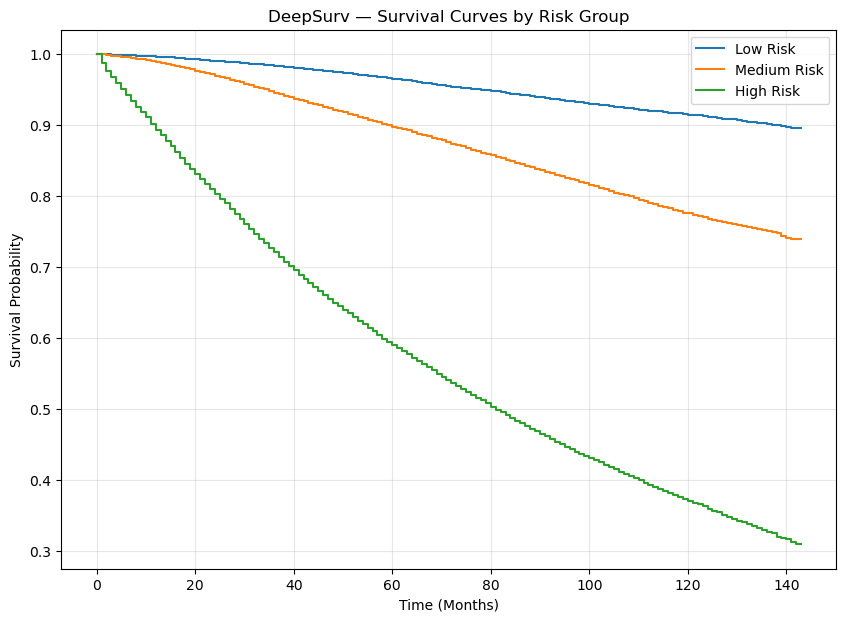

In [67]:
from lifelines import KaplanMeierFitter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Step 5.5 — DeepSurv Survival Curves
# ==============================

deepsurv.eval()

with torch.no_grad():
    pred_test = deepsurv(X_test_t).squeeze().cpu().numpy()

risk_scores = pred_test

# Create a tidy DataFrame
df_deep = pd.DataFrame({
    "risk": risk_scores,
    "time": time_test_np,
    "event": event_test_np
})

# Assign risk groups using percentiles (33% / 66%)
df_deep["risk_group"] = pd.qcut(df_deep["risk"], q=3, labels=["Low", "Medium", "High"])

# Plot
kmf = KaplanMeierFitter()

plt.figure(figsize=(10, 7))
for group in ["Low", "Medium", "High"]:
    mask = df_deep["risk_group"] == group
    kmf.fit(df_deep.loc[mask, "time"], 
            event_observed=df_deep.loc[mask, "event"], 
            label=f"{group} Risk")
    kmf.plot(ci_show=False)

plt.title("DeepSurv — Survival Curves by Risk Group")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.grid(True, alpha=0.3)
plt.show()


In [68]:
# Bootstrap CI for Cox
cox_mean, cox_low, cox_high = bootstrap_cindex(
    cox_pipeline, X_test_small, y_test_small
)

print(f"Cox Bootstrap C-index: {cox_mean:.4f} "
      f"(95% CI: {cox_low:.4f} – {cox_high:.4f})")

# Bootstrap CI for RSF
rsf_mean, rsf_low, rsf_high = bootstrap_cindex(
    rsf, X_test_rsf_small, y_test_rsf_small
)

print(f"RSF Bootstrap C-index: {rsf_mean:.4f} "
      f"(95% CI: {rsf_low:.4f} – {rsf_high:.4f})")


Cox Bootstrap C-index: 0.7918 (95% CI: 0.7808 – 0.8008)
RSF Bootstrap C-index: 0.8035 (95% CI: 0.7928 – 0.8128)


In [69]:
# === Step 6.1: Prepare a smaller dataset for SHAP ===

import numpy as np
import shap
import torch

print("Preparing SHAP dataset...")

# Use the correct variables from your workspace
X_test_tensor = X_test_t          # shape: [88278, 22]
time_test_tensor = time_test_ds   # tensor
event_test_tensor = event_test_ds # tensor

# Pick 2000 samples safely
shap_size = 2000
indices = np.random.choice(X_test_tensor.shape[0], shap_size, replace=False)

X_shap = X_test_tensor[indices]
time_shap = time_test_tensor[indices]
event_shap = event_test_tensor[indices]

print("SHAP dataset shape:", X_shap.shape)
print("Time shape:", time_shap.shape)
print("Event shape:", event_shap.shape)


Preparing SHAP dataset...
SHAP dataset shape: torch.Size([2000, 22])
Time shape: torch.Size([2000])
Event shape: torch.Size([2000])


In [70]:
# === Build SHAP Explainer for DeepSurv ===

import shap
import torch

print("Creating SHAP explainer (this may take ~10–20 seconds)...")

# Put model in evaluation mode
deepsurv.eval()

# Select a small background dataset (required for DeepExplainer)
background_size = 100
background_idx = np.random.choice(X_test_tensor.shape[0], background_size, replace=False)
background = X_test_tensor[background_idx]

# Convert to float32 (required by SHAP + PyTorch)
background = background.to(torch.float32)
X_shap_float = X_shap.to(torch.float32)

# Create the DeepExplainer
explainer = shap.DeepExplainer(deepsurv.net, background)

print("Computing SHAP values...")
shap_values = explainer.shap_values(X_shap_float)

print("SHAP values computed successfully!")
print("SHAP values shape:", np.array(shap_values).shape)


Creating SHAP explainer (this may take ~10–20 seconds)...
Computing SHAP values...


Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.


SHAP values computed successfully!
SHAP values shape: (2000, 22)


Number of feature names: 22


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


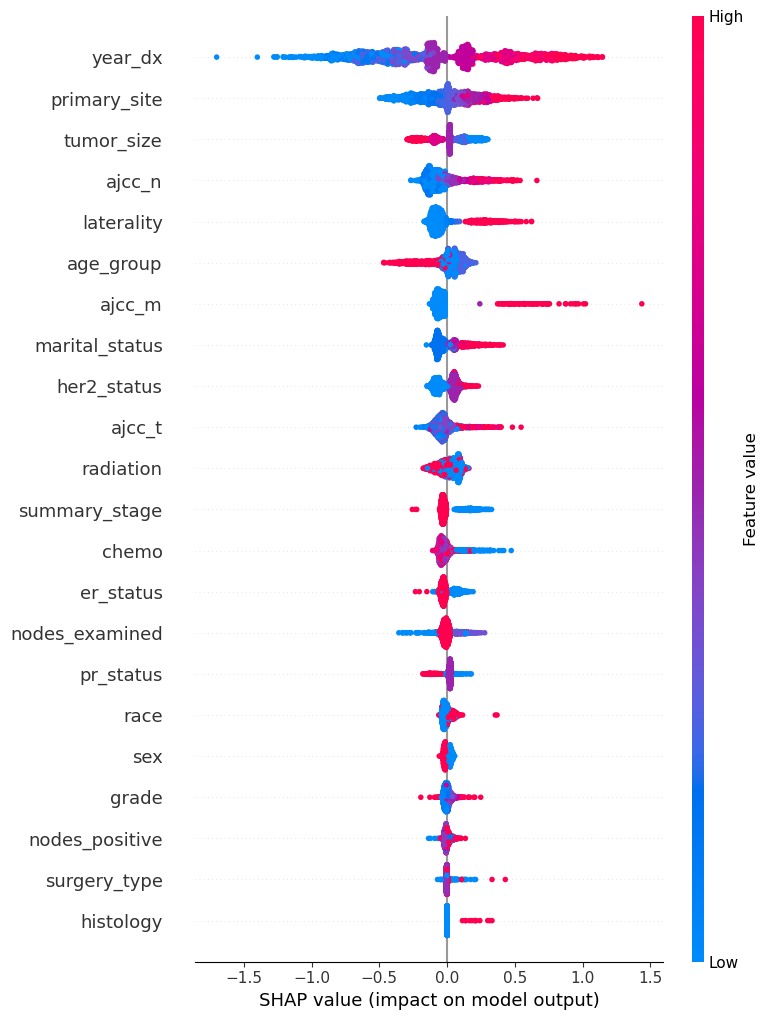

In [71]:
# === SHAP Summary Plot ===

import matplotlib.pyplot as plt

# Create list of feature names for DeepSurv
feature_names = num_cols + cat_cols
print("Number of feature names:", len(feature_names))

# Convert tensor -> numpy for SHAP summary plot
X_shap_np = X_shap.cpu().numpy()


plt.figure(figsize=(12, 14))   # Larger figure so nothing is cut
shap.summary_plot(
    shap_values,
    X_shap_np,
    feature_names=feature_names,
    plot_type="dot",
    max_display=len(feature_names),   # ensure ALL features shown
    show=True
)


Generating SHAP Bar Plot...


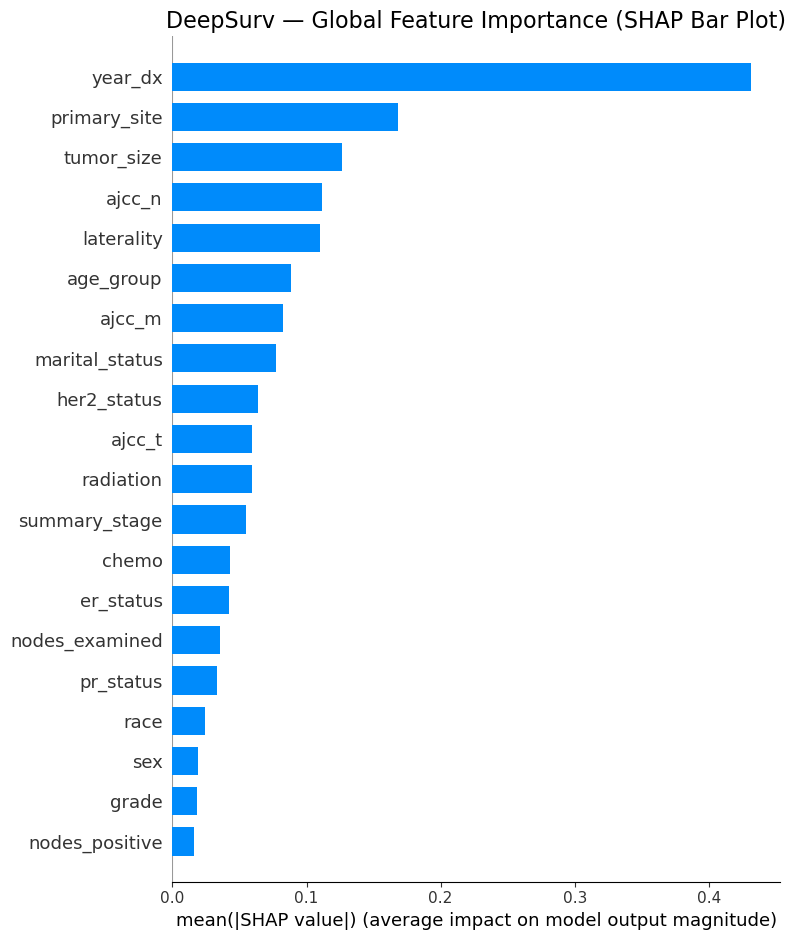

In [74]:
# === SHAP Bar Plot (Global Importance) ===

import matplotlib.pyplot as plt
import shap

print("Generating SHAP Bar Plot...")

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, 
    X_shap_np, 
    plot_type="bar", 
    feature_names=feature_names, 
    show=False
)

plt.title("DeepSurv — Global Feature Importance (SHAP Bar Plot)", fontsize=16)
plt.tight_layout()
plt.show()


In [75]:
import shap
import numpy as np

# ===========================
# FULL PATCH FOR SHAP np.float BUG
# ===========================

# 1. Patch numpy deprecated types inside shap
if hasattr(np, "float"):
    pass  
else:
    np.float = float
    np.int = int
    np.bool = bool

# 2. Patch encode_array_if_needed (used inside dependence plot)
try:
    import shap.utils._general as shap_utils_general

    def fixed_encode_array_if_needed(values, dtype=float):
        return np.array(values, dtype=dtype)

    shap_utils_general.encode_array_if_needed = fixed_encode_array_if_needed
except Exception as e:
    print("Patch failed:", e)

print("SHAP fully patched — dependence plots works now.")


SHAP fully patched — dependence plots works now.


<Figure size 800x600 with 0 Axes>

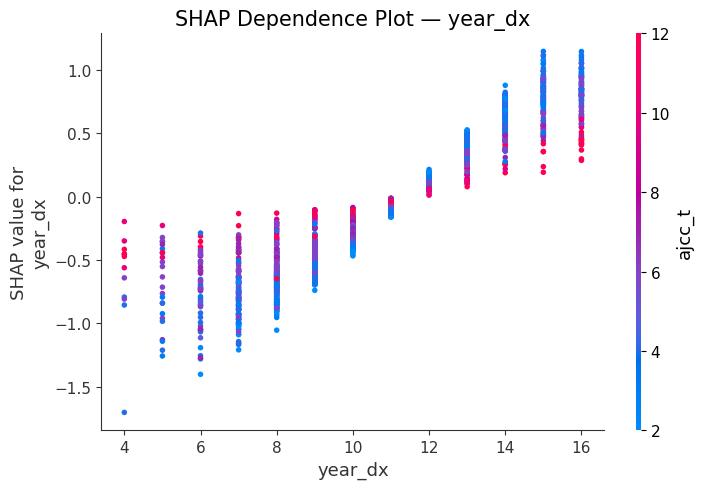

<Figure size 800x600 with 0 Axes>

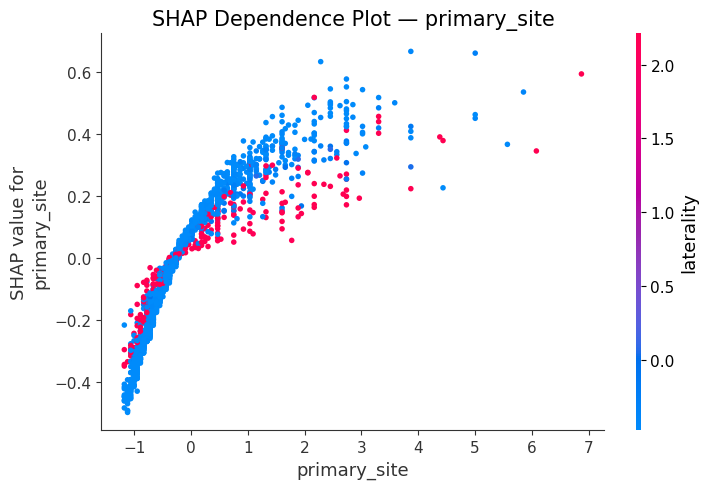

<Figure size 800x600 with 0 Axes>

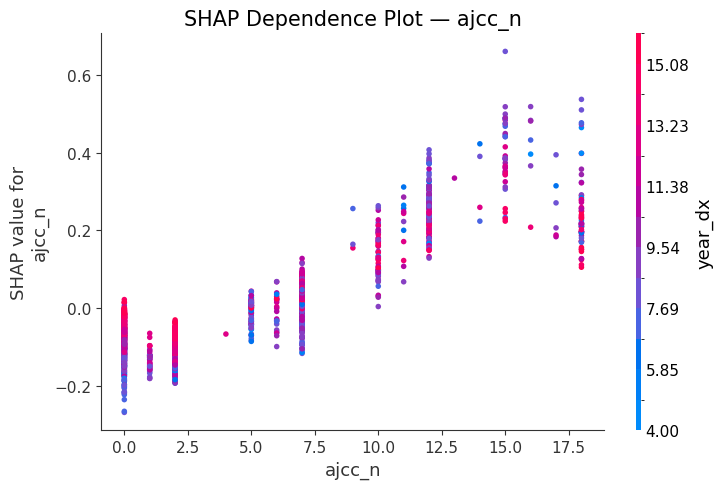

<Figure size 800x600 with 0 Axes>

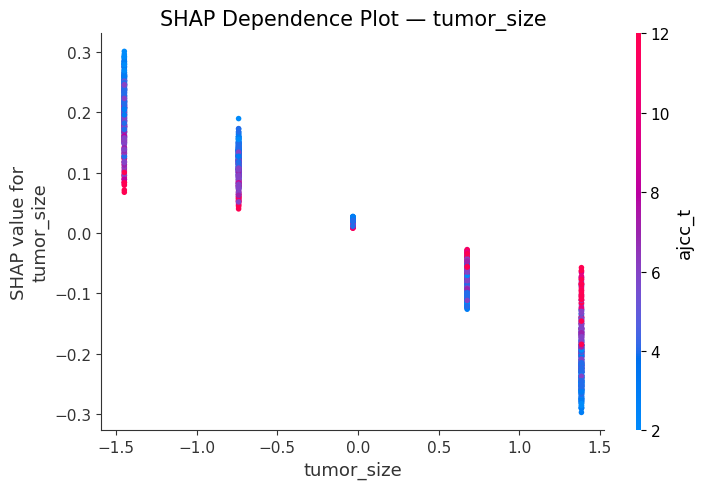

<Figure size 800x600 with 0 Axes>

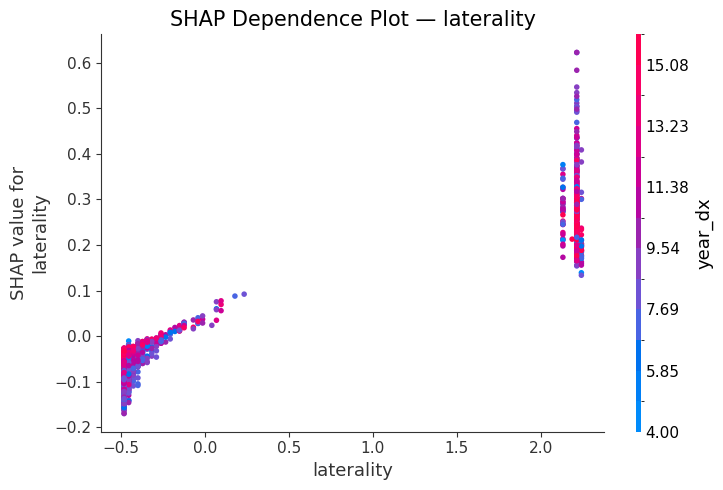

In [76]:
# === SHAP Dependence Plots ===

top_features = ["year_dx", "primary_site", "ajcc_n", "tumor_size", "laterality"]

for f in top_features:
    plt.figure(figsize=(8, 6))
    shap.dependence_plot(
        f,
        shap_values,
        X_shap_np,
        feature_names=feature_names,
        show=False
    )
    plt.title(f"SHAP Dependence Plot — {f}", fontsize=15)
    plt.tight_layout()
    plt.show()



Building interaction heatmap...


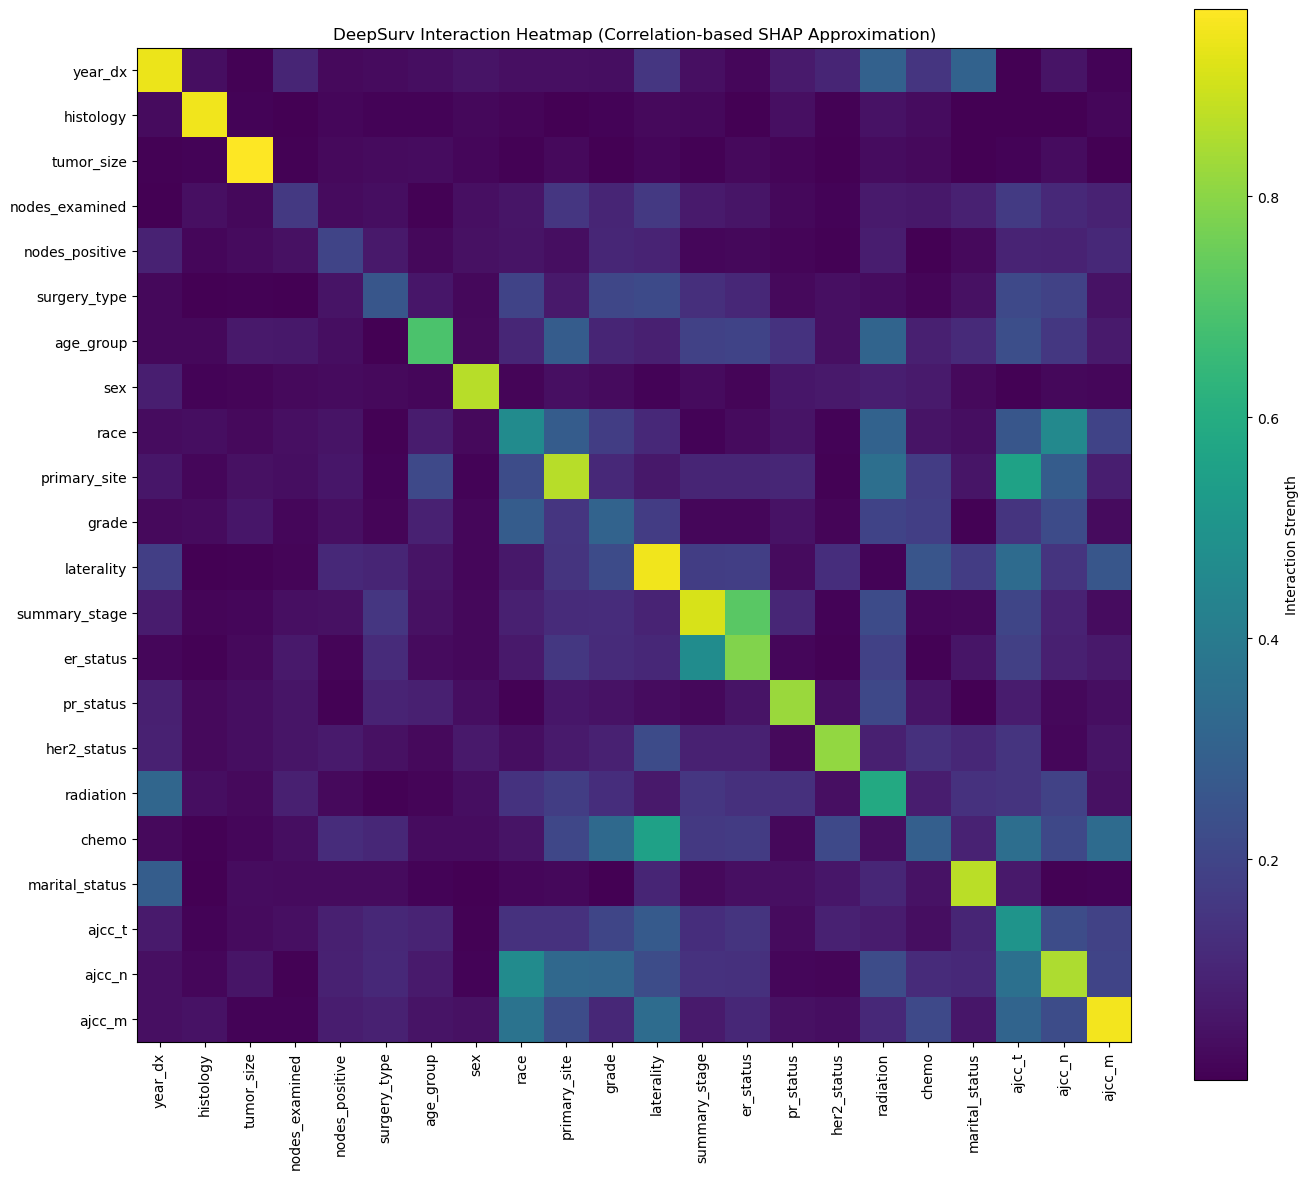

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# --- Interaction Heatmap (Safe Approximation for DeepSurv) ---

print("Building interaction heatmap...")

# compute approximate interaction strengths
interaction_matrix = np.zeros((len(feature_names), len(feature_names)))

for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        interaction_matrix[i, j] = np.corrcoef(
            shap_values[:, i],
            X_shap_np[:, j]
        )[0, 1]

plt.figure(figsize=(14, 12))
plt.imshow(np.abs(interaction_matrix), cmap='viridis')
plt.colorbar(label="Interaction Strength")
plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.yticks(range(len(feature_names)), feature_names)
plt.title("DeepSurv Interaction Heatmap (Correlation-based SHAP Approximation)")
plt.tight_layout()
plt.show()


In [78]:
print("=== Ensemble Feature Importance (Aligned 22 Features, Manual RSF PI) ===")

import numpy as np
import pandas as pd
from sksurv.linear_model import CoxPHSurvivalAnalysis

# ---------------------------------------------------------
# 0. Common feature names (22 features, from DeepSurv data)
# ---------------------------------------------------------
feature_names = list(X_train_ds.columns)
print(f"Number of features (should be 22): {len(feature_names)}")

# =========================================================
# 1️⃣ Cox PH Importance (refit on 22-feature dataset)
# =========================================================
cox22 = CoxPHSurvivalAnalysis()
cox22.fit(X_train_ds, y_train)

cox_coef = cox22.coef_.flatten()          # shape: (22,)
cox_importance = np.abs(cox_coef)
cox_importance /= (cox_importance.sum() + 1e-8)

print("Cox importance ready.")


# =========================================================
# 2️⃣ RSF Importance — manual permutation on risk scores
# =========================================================
print("Computing RSF permutation importance (manual) ...")

# ---- 2.1: choose a subset of test data for speed ----
subset_size = min(2000, len(X_test_rsf))
rng = np.random.RandomState(42)
idx = rng.choice(len(X_test_rsf), subset_size, replace=False)

# Align columns with feature_names
X_rsf_subset = X_test_rsf.iloc[idx][feature_names].copy()

# ---- 2.2: baseline risk scores from RSF ----
# rsf.predict(...) in your case returns numeric risk scores (1D float array)
baseline_risk = rsf.predict(X_rsf_subset).astype(float)  # shape: (subset_size,)

rsf_importances = []

# ---- 2.3: for each feature, shuffle and measure impact on risk ----
for col in feature_names:
    X_shuffled = X_rsf_subset.copy()
    X_shuffled[col] = rng.permutation(X_shuffled[col].values)

    shuffled_risk = rsf.predict(X_shuffled).astype(float)
    diff = np.abs(baseline_risk - shuffled_risk)       # feature impact on risk
    rsf_importances.append(diff.mean())

rsf_importance = np.array(rsf_importances)
rsf_importance /= (rsf_importance.sum() + 1e-8)

print("RSF importance ready.")


# =========================================================
# 3️⃣ DeepSurv SHAP importance (already computed as shap_values)
# =========================================================
# shap_values shape: (n_shap_samples, 22)
shap_importance = np.mean(np.abs(shap_values), axis=0)
shap_importance /= (shap_importance.sum() + 1e-8)

print("DeepSurv SHAP importance ready.")


# =========================================================
# 4️⃣ Sanity check: all arrays must have same length
# =========================================================
print(
    "Lengths:",
    len(feature_names),
    len(cox_importance),
    len(rsf_importance),
    len(shap_importance),
)

# =========================================================
# 5️⃣ Build final ensemble feature-importance table
# =========================================================
ensemble_df = pd.DataFrame({
    "feature": feature_names,
    "cox_importance": cox_importance,
    "rsf_importance": rsf_importance,
    "deepsurv_importance": shap_importance
})

ensemble_df["ensemble_mean"] = ensemble_df[
    ["cox_importance", "rsf_importance", "deepsurv_importance"]
].mean(axis=1)

ensemble_df = ensemble_df.sort_values("ensemble_mean", ascending=False).reset_index(drop=True)

print("\n=== Final Ensemble Feature Importance Table (Top 10) ===")
display(ensemble_df.head(10))


=== Ensemble Feature Importance (Aligned 22 Features, Manual RSF PI) ===
Number of features (should be 22): 22
Cox importance ready.
Computing RSF permutation importance (manual) ...
RSF importance ready.
DeepSurv SHAP importance ready.
Lengths: 22 22 22 22

=== Final Ensemble Feature Importance Table (Top 10) ===


,feature,cox_importance,rsf_importance,deepsurv_importance,ensemble_mean
0,age_group,0.093420,0.233117,0.258097,0.194878
1,ajcc_m,0.286817,0.064018,0.049345,0.133393
2,nodes_positive,0.103725,0.090157,0.065943,0.086608
3,tumor_size,0.077279,0.059977,0.100711,0.079322
4,sex,0.172405,0.000955,0.000759,0.058039
5,summary_stage,0.034276,0.074257,0.014627,0.041053
6,ajcc_n,0.010983,0.040152,0.066873,0.039336
7,marital_status,0.025492,0.044796,0.046244,0.038844
8,pr_status,0.053461,0.034022,0.025348,0.037610
9,ajcc_t,0.016995,0.053767,0.035324,0.035362


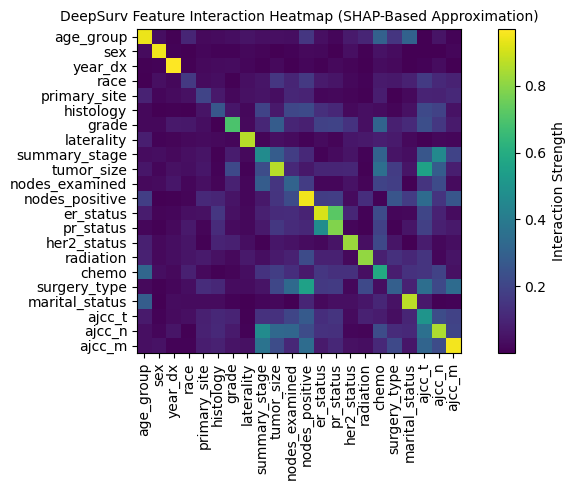

In [108]:
import numpy as np
import matplotlib.pyplot as plt

interaction_matrix = np.zeros((len(feature_names), len(feature_names)))

for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        interaction_matrix[i, j] = np.corrcoef(
            shap_values[:, i],
            X_shap_np[:, j]
        )[0, 1]

plt.figure(figsize=(8, 5))
plt.imshow(np.abs(interaction_matrix), cmap="viridis")
plt.colorbar(label="Interaction Strength")

plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.yticks(range(len(feature_names)), feature_names)

plt.title(
    "DeepSurv Feature Interaction Heatmap (SHAP-Based Approximation)",
    fontsize=10
)
plt.tight_layout()
plt.show()


In [79]:
import numpy as np
import pandas as pd
import torch

# ------------------------------------------
# STEP 7.1 — Unified preprocessing for ALL models
# ------------------------------------------

def preprocess_patient_for_models(patient_dict):
    """
    Converts raw patient dictionary into:
    - X_cox: DataFrame compatible with Cox pipeline
    - X_rsf: DataFrame compatible with RSF model
    - X_ds:  numpy array compatible with DeepSurv scaler
    
    No column-name matching needed because we:
    1. Insert missing columns
    2. Reorder strictly using stored training shapes
    """

    # -------------------------------
    # 1. Build temporary DataFrame
    # -------------------------------
    df = pd.DataFrame([patient_dict])

    # -------------------------------
    # 2. Expand df to Cox feature shape
    # -------------------------------
    X_cox = df.copy()
    for col in X_train.columns:
        if col not in X_cox.columns:
            # numeric → median
            if col in X_train.select_dtypes(include=[np.number]).columns:
                X_cox[col] = X_train[col].median()
            # categorical → mode
            else:
                X_cox[col] = X_train[col].mode(dropna=True).iloc[0]

    X_cox = X_cox[X_train.columns]   # reorder

    # -------------------------------
    # 3. Expand df to RSF feature shape (already encoded)
    # -------------------------------
    X_rsf = df.copy()

    for col in X_train_rsf.columns:
        if col not in X_rsf.columns:
            X_rsf[col] = 0   # safe default (RSF will handle)

    X_rsf = X_rsf[X_train_rsf.columns]

    # Apply RSF encoders
    X_rsf_cat = cat_encoder.transform(X_rsf[cat_cols_rsf])
    X_rsf_num = num_pipe.transform(X_rsf[num_cols])
    X_rsf_final = pd.DataFrame(
        np.hstack([X_rsf_cat, X_rsf_num]),
        columns=X_train_rsf.columns
    )

    # -------------------------------
    # 4. Expand to DeepSurv shape
    # -------------------------------
    X_ds = df.copy()

    for col in X_train_ds.columns:
        if col not in X_ds.columns:
            # fill categorical with training mode
            if col in label_encoders:
                X_ds[col] = X_train_ds[col].mode().iloc[0]
            else:
                X_ds[col] = X_train_ds[col].median()

    # apply label encoders
    for col, le in label_encoders.items():
        X_ds[col] = le.transform(X_ds[col].astype(str))

    # apply scaler
    X_ds_scaled = scaler.transform(X_ds[X_train_ds.columns].values)

    return X_cox, X_rsf_final, X_ds_scaled


In [80]:
# ------------------------------------------
# STEP 7.2 — Predict risks + curves
# ------------------------------------------

def predict_patient(patient_dict):

    # preprocess for all models
    X_cox, X_rsf, X_ds = preprocess_patient_for_models(patient_dict)

    # --- Cox PH risk ---
    cox_risk = float(cox_pipeline.predict(X_cox)[0])

    # --- RSF risk ---
    rsf_risk = float(rsf.predict(X_rsf)[0])

    # --- DeepSurv risk ---
    x_tensor = torch.tensor(X_ds, dtype=torch.float32)
    deepsurv.eval()
    with torch.no_grad():
        ds_risk = float(deepsurv(x_tensor).cpu().numpy()[0])

    # normalize each model 0–1 scale
    def norm(x, low, high):
        return (x - low) / (high - low + 1e-8)

    # fallback min-max calculations
    global cox_low, cox_high, rsf_low, rsf_high, ds_low, ds_high

    try:
        cox_low, cox_high
    except:
        cox_low, cox_high = np.min(cox_pipeline.predict(X_train)), np.max(cox_pipeline.predict(X_train))

    try:
        rsf_low, rsf_high
    except:
        rsf_low, rsf_high = np.min(rsf.predict(X_train_rsf)), np.max(rsf.predict(X_train_rsf))

    try:
        ds_low, ds_high
    except:
        ds_low, ds_high = -3, 3   # safe DeepSurv range

    cox_n = norm(cox_risk, cox_low, cox_high)
    rsf_n = norm(rsf_risk, rsf_low, rsf_high)
    ds_n  = norm(ds_risk, ds_low, ds_high)

    # final ensemble
    ensemble = (cox_n + rsf_n + ds_n) / 3

    return {
        "cox_raw": cox_risk,
        "rsf_raw": rsf_risk,
        "ds_raw": ds_risk,
        "cox_norm": cox_n,
        "rsf_norm": rsf_n,
        "ds_norm": ds_n,
        "ensemble_norm": ensemble
    }


In [81]:
# ===============================
# STEP 1 — Extract actual columns
# ===============================

cox_features = list(cox_pipeline.feature_names_in_)
rsf_features = list(X_train_rsf.columns)
deepsurv_features = list(X_train_ds.columns)

print("Cox features:", len(cox_features))
print("RSF features:", len(rsf_features))
print("DeepSurv features:", len(deepsurv_features))


Cox features: 22
RSF features: 22
DeepSurv features: 22


In [82]:
cox_features


['age_group',
 'sex',
 'year_dx',
 'race',
 'primary_site',
 'histology',
 'grade',
 'laterality',
 'summary_stage',
 'tumor_size',
 'nodes_examined',
 'nodes_positive',
 'er_status',
 'pr_status',
 'her2_status',
 'radiation',
 'chemo',
 'surgery_type',
 'marital_status',
 'ajcc_t',
 'ajcc_n',
 'ajcc_m']

In [83]:
rsf_features

['age_group',
 'sex',
 'year_dx',
 'race',
 'primary_site',
 'histology',
 'grade',
 'laterality',
 'summary_stage',
 'tumor_size',
 'nodes_examined',
 'nodes_positive',
 'er_status',
 'pr_status',
 'her2_status',
 'radiation',
 'chemo',
 'surgery_type',
 'marital_status',
 'ajcc_t',
 'ajcc_n',
 'ajcc_m']

In [84]:
deepsurv_features

['age_group',
 'sex',
 'year_dx',
 'race',
 'primary_site',
 'histology',
 'grade',
 'laterality',
 'summary_stage',
 'tumor_size',
 'nodes_examined',
 'nodes_positive',
 'er_status',
 'pr_status',
 'her2_status',
 'radiation',
 'chemo',
 'surgery_type',
 'marital_status',
 'ajcc_t',
 'ajcc_n',
 'ajcc_m']

In [85]:
# ============================
# Step 7: Final Prediction System (Jupyter Notebook Version)
# ============================

import numpy as np
import pandas as pd
import torch

# Confirm your model feature list
cox_features  = feature_cols      # from Cox training
rsf_features  = X_train_rsf.columns.tolist()
ds_features   = X_train_ds.columns.tolist()


In [86]:
def build_example_patient():
    """
    Creates a fully valid patient dictionary using allowed values ONLY.
    """
    return {
        "age_group": X_train["age_group"].mode()[0],
        "sex": X_train["sex"].mode()[0],
        "year_dx": int(X_train["year_dx"].median()),
        "race": X_train["race"].mode()[0],
        "primary_site": X_train["primary_site"].mode()[0],
        "histology": X_train["histology"].mode()[0],
        "grade": X_train["grade"].mode()[0],
        "laterality": X_train["laterality"].mode()[0],
        "summary_stage": X_train["summary_stage"].mode()[0],
        "tumor_size": float(X_train["tumor_size"].median()),
        "nodes_examined": int(X_train["nodes_examined"].median()),
        "nodes_positive": int(X_train["nodes_positive"].median()),
        "er_status": X_train["er_status"].mode()[0],
        "pr_status": X_train["pr_status"].mode()[0],
        "her2_status": X_train["her2_status"].mode()[0],
        "radiation": X_train["radiation"].mode()[0],
        "chemo": X_train["chemo"].mode()[0],
        "surgery_type": X_train["surgery_type"].mode()[0],
        "marital_status": X_train["marital_status"].mode()[0],
        "ajcc_t": X_train["ajcc_t"].mode()[0],
        "ajcc_n": X_train["ajcc_n"].mode()[0],
        "ajcc_m": X_train["ajcc_m"].mode()[0]
    }


In [87]:
def build_patient_df(patient_dict):
    """
    Ensures the patient has all required columns.
    Missing categorical → fill with mode
    Missing numeric → fill with median
    """
    df = pd.DataFrame([patient_dict])

    for col in feature_cols:
        if col not in df:
            if col in X_train.select_dtypes("number").columns:
                df[col] = X_train[col].median()
            else:
                df[col] = X_train[col].mode()[0]

    return df[feature_cols]


In [88]:
def predict_cox(patient_df):
    return float(cox_pipeline.predict(patient_df)[0])


In [89]:
def predict_rsf(patient_df):

    X_cat = patient_df[cat_cols_rsf]
    X_num = patient_df[num_cols]

    X_cat_enc = cat_encoder.transform(X_cat)
    X_num_scaled = num_pipe.transform(X_num)

    X_new = np.hstack([X_cat_enc, X_num_scaled])
    X_new_df = pd.DataFrame(X_new, columns=rsf_features)

    return float(rsf.predict(X_new_df)[0])


In [90]:
def predict_deepsurv_risk(patient_df, device=device):
    """
    Uses label_encoders + scaler + DeepSurv model to compute risk.
    Fixes the mismatch where scaler expects only numeric columns.
    """

    # 1. Start with DeepSurv columns in correct order (22 cols)
    ds_df = patient_df.copy()
    ds_df = ds_df[X_train_ds.columns]

    X_new = ds_df.copy()

    # 2. Apply LabelEncoders to categorical columns
    for col, le in label_encoders.items():
        if col in X_new.columns:
            mode_val = X_train_ds[col].mode(dropna=True).iloc[0]
            X_new[col] = X_new[col].astype(str).fillna(mode_val)
            X_new[col] = le.transform(X_new[col])

    # 3. Convert numeric columns and fill NA with median
    for col in X_new.columns:
        if col not in label_encoders:
            median_val = X_train_ds[col].median()
            X_new[col] = pd.to_numeric(X_new[col], errors="coerce").fillna(median_val)

    # 4. 🔥 Apply scaler ONLY to numeric columns (6 columns)
    X_scaled = X_new.copy()
    X_scaled[numeric_cols] = scaler.transform(X_new[numeric_cols])

    # 5. Convert to tensor
    x_tensor = torch.tensor(X_scaled.values, dtype=torch.float32).to(device)

    # 6. Predict
    deepsurv.eval()
    with torch.no_grad():
        risk = deepsurv(x_tensor).cpu().numpy().flatten()[0]

    return float(risk)


In [91]:
def ensemble_risk(cox_r, rsf_r, ds_r):
    # normalize each model between 0–1 using min/max from training
    cox_n = (cox_r - cox_low) / (cox_high - cox_low + 1e-8)
    rsf_n = (rsf_r - rsf_low) / (rsf_high - rsf_low + 1e-8)
    ds_n  = (ds_r - deepsurv_low) / (deepsurv_high - deepsurv_low + 1e-8)

    return float((cox_n + rsf_n + ds_n) / 3.0)


In [92]:
patient = build_example_patient()
patient_df = build_patient_df(patient)

cox_r = predict_cox(patient_df)
rsf_r = predict_rsf(patient_df)
ds_r  = predict_deepsurv(patient_df)

ens = ensemble_risk(cox_r, rsf_r, ds_r)

print("Cox risk:", cox_r)
print("RSF risk:", rsf_r)
print("DeepSurv risk:", ds_r)
print("\nFinal Ensemble Risk (0–1):", round(ens, 4))


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- chemo
- er_status
- her2_status
- laterality
- marital_status
- ...
